<a href="https://colab.research.google.com/github/Innov8iveGuru/Python/blob/main/GANImage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Setup and Imports
Start by setting up the environment and importing the required libraries.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


Step 2: Loading and Preprocessing MNIST Dataset
Next, we’ll load the MNIST dataset using PyTorch’s torchvision.datasets and apply transformations like normalization.

In [ ]:
# MNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)


Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9.91M/9.91M [00:00<00:00, 34.3MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1.65M/1.65M [00:00<00:00, 9.68MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4.54k/4.54k [00:00<00:00, 2.67MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



Step 3: Building the Generator and Discriminator Networks
We’ll define two classes: Generator and Discriminator. The generator creates synthetic images, while the discriminator attempts to classify real vs. fake images.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x.view(-1, 28*28))


Step 4: Training the GAN
We need to define the loss function (binary cross-entropy) and optimizers for both the generator and the discriminator.

In [6]:
# Initialize the generator and discriminator
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and optimizer
criterion = nn.BCELoss()
optimizer_g = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_d = optim.Adam(discriminator.parameters(), lr=0.0002)

# Training loop
epochs = 50
for epoch in range(epochs):
    for batch_idx, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Train discriminator: max log(D(x)) + log(1 - D(G(z)))
        optimizer_d.zero_grad()
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        outputs = discriminator(real_images)
        d_loss_real = criterion(outputs, real_labels)

        z = torch.randn(batch_size, 100).to(device)
        fake_images = generator(z)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = criterion(outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_d.step()

        # Train generator: min log(1 - D(G(z))) <=> max log(D(G(z)))
        optimizer_g.zero_grad()
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        optimizer_g.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch [1/50] | D Loss: 0.0249 | G Loss: 5.3347
Epoch [2/50] | D Loss: 0.3079 | G Loss: 6.7549
Epoch [3/50] | D Loss: 0.5559 | G Loss: 4.0144
Epoch [4/50] | D Loss: 0.6249 | G Loss: 2.4026
Epoch [5/50] | D Loss: 0.2751 | G Loss: 4.4646
Epoch [6/50] | D Loss: 0.1535 | G Loss: 4.3313
Epoch [7/50] | D Loss: 0.2220 | G Loss: 4.6301
Epoch [8/50] | D Loss: 0.4040 | G Loss: 3.6560
Epoch [9/50] | D Loss: 0.4140 | G Loss: 3.1467
Epoch [10/50] | D Loss: 0.3315 | G Loss: 4.1256
Epoch [11/50] | D Loss: 1.0532 | G Loss: 3.5871
Epoch [12/50] | D Loss: 0.4665 | G Loss: 2.5488
Epoch [13/50] | D Loss: 0.6677 | G Loss: 2.6044
Epoch [14/50] | D Loss: 0.5682 | G Loss: 2.5437
Epoch [15/50] | D Loss: 0.6186 | G Loss: 2.4525
Epoch [16/50] | D Loss: 0.5445 | G Loss: 2.8761
Epoch [17/50] | D Loss: 0.3529 | G Loss: 3.4127
Epoch [18/50] | D Loss: 0.2171 | G Loss: 4.3038
Epoch [19/50] | D Loss: 0.5086 | G Loss: 2.4687
Epoch [20/50] | D Loss: 0.7891 | G Loss: 2.4300
Epoch [21/50] | D Loss: 0.3742 | G Loss: 3.4065
E

Step 5: Visualizing Generated Images
After training the GAN, we’ll generate and visualize the images.

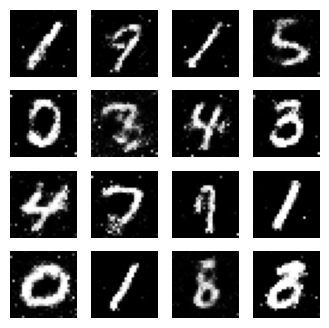

In [40]:
def generate_and_show_images(generator, num_images=16):
    generator.eval()
    z = torch.randn(num_images, 100).to(device)
    fake_images = generator(z)
    fake_images = fake_images.cpu().detach()

    # Plotting the generated images
    plt.figure(figsize=(4, 4))
    for i in range(num_images):
        plt.subplot(4, 4, i + 1)
        plt.imshow(fake_images[i].squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

# Generate images after training
generate_and_show_images(generator)
